# Project 07: Product Performance Analysis
### Which Products Drive Revenue, Which Are Quietly Dying, and What the Sales Cycle Looks Like

---

## Business Brief

Most product catalogues follow an 80/20 pattern: a small number of products drive the majority of revenue while a large number of products sit on shelves generating minimal return. But which products fall into which category changes over time, and most businesses are too slow to notice.

This project analyses product-level sales performance and answers:

1. Which products and categories drive the most revenue?
2. How does product performance change across months and quarters?
3. What does the order size distribution look like per product?
4. Which products are worth investing in vs phasing out?
5. Unique finding: a product concentration risk score showing how dependent the business is on its top sellers

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | Sample Sales Data |
| **Direct Link** | https://www.kaggle.com/datasets/kyanyoga/sample-sales-data |
| **Records** | 2,800+ orders across 100+ products |
| **Features** | Order date, product line, quantity, price, customer, territory |

## Tools
`Python` `Pandas` `SQL (sqlite3)` `Plotly` `Seaborn` `Matplotlib` `NumPy`

---

## What Makes This Different

- Auto-detects file path and column names so it runs without manual edits
- Uses SQL for all product-level aggregations
- Builds an 80/20 Pareto analysis on products and categories
- Introduces a Product Concentration Risk Score
- Classifies every product into a performance quadrant (Stars, Cash Cows, Question Marks, Dogs)
- Interactive treemap showing revenue hierarchy by category and product


---
## Section 1: Setup

In [1]:
import sqlite3, warnings, os, glob
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'star':     '#F59E0B',
    'cow':      '#10B981',
    'question': '#6366F1',
    'dog':      '#EF4444',
    'primary':  '#3B82F6',
    'bg':       '#F8FAFC',
    'border':   '#E2E8F0',
    'text':     '#1E293B',
    'subtext':  '#64748B',
    'dark':     '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')


Setup complete.


---
## Section 2: Load Data

In [2]:
# Auto-detect CSV file path
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('CSV files found:')
for f in csv_files:
    print(f'  {f}')


CSV files found:
  /kaggle/input/datasets/kyanyoga/sample-sales-data/sales_data_sample.csv


In [3]:
# Load the sales data file
# Update this path if the auto-detection above shows a different filename
DATA_PATH = '/kaggle/input/datasets/kyanyoga/sample-sales-data/sales_data_sample.csv'

# Try loading with different encodings
for encoding in ['latin-1', 'utf-8', 'ISO-8859-1']:
    try:
        df = pd.read_csv(DATA_PATH, encoding=encoding)
        print(f'Loaded with encoding: {encoding}')
        break
    except Exception as e:
        print(f'Failed with {encoding}: {e}')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
print(df.columns.tolist())
print()
print('Sample:')
print(df.head(3).T)


Loaded with encoding: latin-1
Shape: 2,823 rows x 25 columns

Columns:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Sample:
                                        0                   1  \
ORDERNUMBER                         10107               10121   
QUANTITYORDERED                        30                  34   
PRICEEACH                            95.7               81.35   
ORDERLINENUMBER                         2                   5   
SALES                              2871.0              2765.9   
ORDERDATE                  2/24/2003 0:00       5/7/2003 0:00   
STATUS                            Shipped             Shipped   
QTR_ID                                  1                   2   
MO

---
## Section 3: Prepare and Standardise

In [4]:
# Standardise column names to lowercase with underscores
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)
print('Standardised columns:')
print(df.columns.tolist())


Standardised columns:
['ordernumber', 'quantityordered', 'priceeach', 'orderlinenumber', 'sales', 'orderdate', 'status', 'qtr_id', 'month_id', 'year_id', 'productline', 'msrp', 'productcode', 'customername', 'phone', 'addressline1', 'addressline2', 'city', 'state', 'postalcode', 'country', 'territory', 'contactlastname', 'contactfirstname', 'dealsize']


In [5]:
# Identify key columns automatically
all_cols = df.columns.tolist()

# Find date column
date_col = next((c for c in all_cols if 'date' in c or 'order' in c and 'date' in c), None)

# Find revenue/sales column
rev_col = next((c for c in all_cols if 'sales' in c or 'revenue' in c or 'amount' in c or 'total' in c), None)

# Find product column
prod_col = next((c for c in all_cols if 'product' in c and ('line' in c or 'name' in c or 'code' in c)), None)
if prod_col is None:
    prod_col = next((c for c in all_cols if 'product' in c), None)

# Find quantity column
qty_col = next((c for c in all_cols if 'quantity' in c or 'qty' in c or 'ordered' in c), None)

# Find order number column
order_col = next((c for c in all_cols if 'order' in c and ('num' in c or 'no' in c or 'id' in c)), None)

print(f'Date column:     {date_col}')
print(f'Revenue column:  {rev_col}')
print(f'Product column:  {prod_col}')
print(f'Quantity column: {qty_col}')
print(f'Order column:    {order_col}')


Date column:     orderdate
Revenue column:  sales
Product column:  productline
Quantity column: quantityordered
Order column:    ordernumber


In [6]:
# Parse date column
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors='coerce')
    df['year']    = df[date_col].dt.year
    df['month']   = df[date_col].dt.month
    df['quarter'] = df[date_col].dt.quarter
    df['month_name'] = df[date_col].dt.strftime('%b')
    print(f'Date range: {df[date_col].min().date()} to {df[date_col].max().date()}')

# Convert revenue to numeric
if rev_col:
    df[rev_col] = pd.to_numeric(df[rev_col], errors='coerce')

# Drop rows missing key values
key_cols = [c for c in [date_col, rev_col, prod_col] if c is not None]
df = df.dropna(subset=key_cols)

print(f'Clean rows:  {len(df):,}')
print(f'Revenue total: {df[rev_col].sum():,.2f}')
if prod_col:
    print(f'Unique products: {df[prod_col].nunique()}')


Date range: 2003-01-06 to 2005-05-31
Clean rows:  2,823
Revenue total: 10,032,628.85
Unique products: 7


---
## Section 4: SQL Product Performance Queries

In [7]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')

# Confirm columns in DB
schema = pd.read_sql_query('PRAGMA table_info(sales)', conn)
print('DB columns:')
print(schema[['name','type']].to_string(index=False))


Loaded into SQLite.
DB columns:
            name      type
     ordernumber   INTEGER
 quantityordered   INTEGER
       priceeach      REAL
 orderlinenumber   INTEGER
           sales      REAL
       orderdate TIMESTAMP
          status      TEXT
          qtr_id   INTEGER
        month_id   INTEGER
         year_id   INTEGER
     productline      TEXT
            msrp   INTEGER
     productcode      TEXT
    customername      TEXT
           phone      TEXT
    addressline1      TEXT
    addressline2      TEXT
            city      TEXT
           state      TEXT
      postalcode      TEXT
         country      TEXT
       territory      TEXT
 contactlastname      TEXT
contactfirstname      TEXT
        dealsize      TEXT
            year   INTEGER
           month   INTEGER
         quarter   INTEGER
      month_name      TEXT


In [8]:
# Revenue by product line
sql_prod = (
    f'SELECT {prod_col},'
    f' ROUND(SUM({rev_col}), 2) as total_revenue,'
    f' COUNT(*) as orders,'
    f' ROUND(AVG({rev_col}), 2) as avg_order_value'
    f' FROM sales'
    f' GROUP BY {prod_col}'
    f' ORDER BY total_revenue DESC'
)
prod_revenue = pd.read_sql_query(sql_prod, conn)
print('=== REVENUE BY PRODUCT LINE ===')
print(prod_revenue.to_string(index=False))


=== REVENUE BY PRODUCT LINE ===
     productline  total_revenue  orders  avg_order_value
    Classic Cars     3919615.66     967          4053.38
    Vintage Cars     1903150.84     607          3135.34
     Motorcycles     1166388.34     331          3523.83
Trucks and Buses     1127789.84     301          3746.81
          Planes      975003.57     306          3186.29
           Ships      714437.13     234          3053.15
          Trains      226243.47      77          2938.23


In [9]:
# Monthly revenue trend
sql_monthly = (
    f'SELECT year, month,'
    f' ROUND(SUM({rev_col}), 2) as revenue,'
    f' COUNT(DISTINCT {order_col if order_col else rev_col}) as orders'
    f' FROM sales'
    f' GROUP BY year, month'
    f' ORDER BY year, month'
)
monthly = pd.read_sql_query(sql_monthly, conn)
print('=== MONTHLY REVENUE ===')
print(monthly.to_string(index=False))


=== MONTHLY REVENUE ===
 year  month    revenue  orders
 2003      1  129753.60       5
 2003      2  140836.19       3
 2003      3  174504.90       6
 2003      4  201609.55       7
 2003      5  192673.11       6
 2003      6  168082.56       6
 2003      7  187731.88       6
 2003      8  197809.30       5
 2003      9  263973.36       8
 2003     10  568290.97      17
 2003     11 1029837.66      28
 2003     12  261876.46       7
 2004      1  316577.42       8
 2004      2  311419.53      10
 2004      3  205733.73       7
 2004      4  206148.12      10
 2004      5  273438.39       8
 2004      6  286674.22      10
 2004      7  327144.09      10
 2004      8  461501.27      12
 2004      9  320750.91      12
 2004     10  552924.25      13
 2004     11 1089048.01      33
 2004     12  372802.66      11
 2005      1  339543.42      12
 2005      2  358186.18      12
 2005      3  374262.76      12
 2005      4  261633.29       9
 2005      5  457861.06      14


In [10]:
# Top products by order frequency vs revenue
if qty_col:
    sql_top = (
        f'SELECT {prod_col},'
        f' COUNT(*) as order_lines,'
        f' ROUND(SUM({rev_col}), 2) as total_revenue,'
        f' ROUND(SUM({qty_col}), 0) as total_units,'
        f' ROUND(AVG({rev_col}), 2) as avg_revenue_per_line'
        f' FROM sales'
        f' GROUP BY {prod_col}'
        f' ORDER BY total_revenue DESC'
    )
else:
    sql_top = (
        f'SELECT {prod_col},'
        f' COUNT(*) as order_lines,'
        f' ROUND(SUM({rev_col}), 2) as total_revenue,'
        f' ROUND(AVG({rev_col}), 2) as avg_revenue_per_line'
        f' FROM sales'
        f' GROUP BY {prod_col}'
        f' ORDER BY total_revenue DESC'
    )
prod_detail = pd.read_sql_query(sql_top, conn)
print('=== DETAILED PRODUCT BREAKDOWN ===')
print(prod_detail.to_string(index=False))


=== DETAILED PRODUCT BREAKDOWN ===
     productline  order_lines  total_revenue  total_units  avg_revenue_per_line
    Classic Cars          967     3919615.66      33992.0               4053.38
    Vintage Cars          607     1903150.84      21069.0               3135.34
     Motorcycles          331     1166388.34      11663.0               3523.83
Trucks and Buses          301     1127789.84      10777.0               3746.81
          Planes          306      975003.57      10727.0               3186.29
           Ships          234      714437.13       8127.0               3053.15
          Trains           77      226243.47       2712.0               2938.23


---
## Section 5: Product Performance Charts

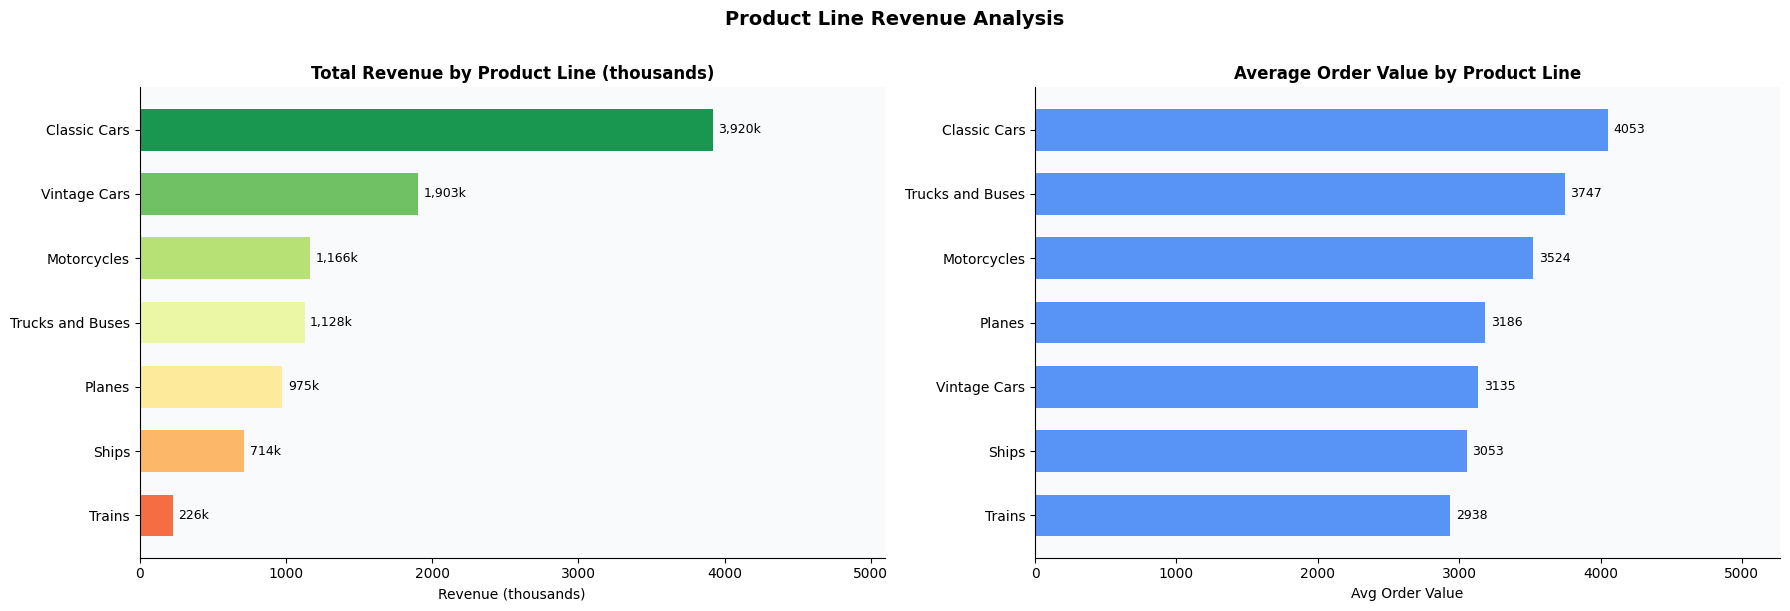

In [11]:
# Revenue by product line
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('white')

prod_sorted = prod_revenue.sort_values('total_revenue', ascending=True)
bar_colors  = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(prod_sorted))
)

bars = axes[0].barh(
    prod_sorted[prod_col],
    prod_sorted['total_revenue'] / 1000,
    color=bar_colors, edgecolor='none', height=0.65
)
axes[0].set_title('Total Revenue by Product Line (thousands)',
                  fontweight='bold')
axes[0].set_xlabel('Revenue (thousands)')
axes[0].set_facecolor(C['bg'])
axes[0].bar_label(bars,
    labels=[f'{v/1000:,.0f}k' for v in prod_sorted['total_revenue']],
    padding=4, fontsize=9
)
axes[0].set_xlim(0, prod_sorted['total_revenue'].max() / 1000 * 1.3)

# Avg order value by product
prod_aov = prod_revenue.sort_values('avg_order_value', ascending=True)
bars2 = axes[1].barh(
    prod_aov[prod_col],
    prod_aov['avg_order_value'],
    color=C['primary'], edgecolor='none', height=0.65, alpha=0.85
)
axes[1].set_title('Average Order Value by Product Line',
                  fontweight='bold')
axes[1].set_xlabel('Avg Order Value')
axes[1].set_facecolor(C['bg'])
axes[1].bar_label(bars2, fmt='%.0f', padding=4, fontsize=9)
axes[1].set_xlim(0, prod_aov['avg_order_value'].max() * 1.3)

plt.suptitle('Product Line Revenue Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/product_revenue.png', dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# Monthly revenue trend
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('period')

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Monthly Revenue Trend', 'Monthly Order Count'),
    vertical_spacing=0.14,
    shared_xaxes=True,
)

fig.add_trace(go.Scatter(
    x=monthly['period'], y=monthly['revenue'],
    mode='lines+markers',
    line=dict(color=C['primary'], width=2.5),
    marker=dict(size=6),
    fill='tozeroy',
    fillcolor='rgba(59,130,246,0.08)',
    name='Revenue',
    hovertemplate='%{x}: %{y:,.0f}<extra></extra>',
), row=1, col=1)

fig.add_trace(go.Bar(
    x=monthly['period'], y=monthly['orders'],
    marker_color=C['question'], opacity=0.75,
    name='Orders',
    hovertemplate='%{x}: %{y:,} orders<extra></extra>',
), row=2, col=1)

fig.update_layout(
    height=520,
    title_text='Sales Performance Over Time',
    title_font_size=15,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    showlegend=True,
    hovermode='x unified',
)
fig.update_xaxes(tickangle=45, tickfont_size=8, row=2, col=1)
fig.update_yaxes(title_text='Revenue', tickformat=',.0f', row=1, col=1)
fig.update_yaxes(title_text='Orders', row=2, col=1)
fig.show()


In [14]:
# Revenue treemap by product line
fig = px.treemap(
    prod_revenue,
    path=[prod_col],
    values='total_revenue',
    color='avg_order_value',
    color_continuous_scale='RdYlGn',
    title='Revenue Treemap by Product Line (colour = avg order value)',
    labels={'total_revenue': 'Total Revenue', 'avg_order_value': 'Avg Order Value'},
)
fig.update_layout(
    height=480,
    paper_bgcolor='white',
)
fig.show()


---
## Section 6: Pareto Analysis (80/20 Rule)

The Pareto principle states that roughly 80% of revenue comes from 20% of products. We test this directly and calculate the exact concentration of revenue across product lines.


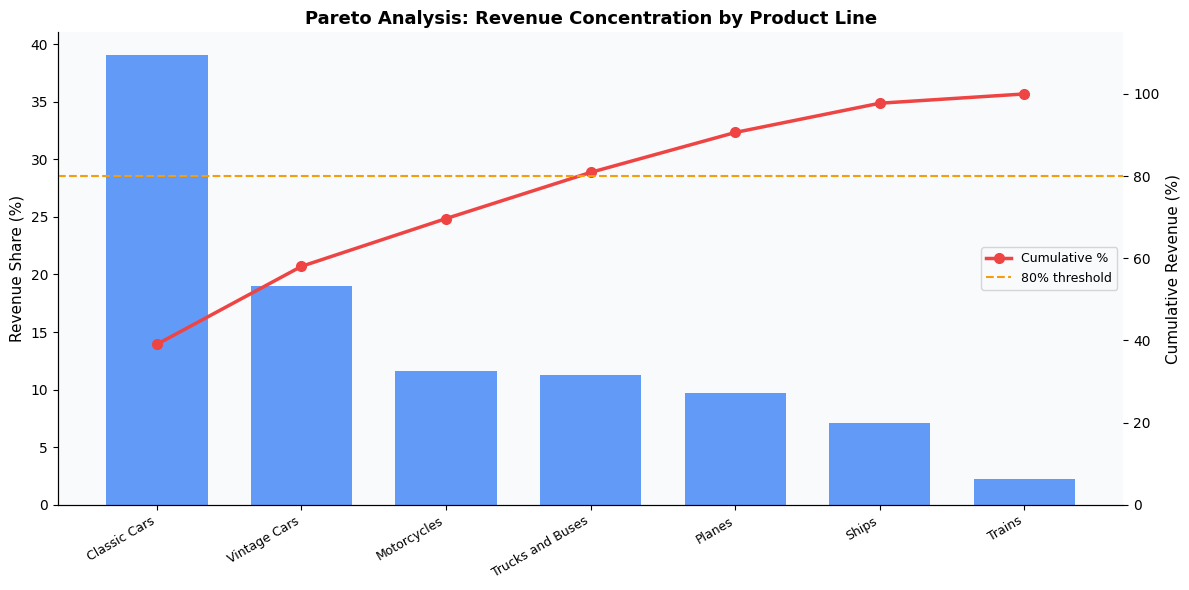

Products needed to reach 80% of revenue: 4 of 7 (57%)


In [15]:
pareto = prod_revenue.sort_values('total_revenue', ascending=False).copy()
pareto['cumulative_revenue'] = pareto['total_revenue'].cumsum()
pareto['cumulative_pct']     = pareto['cumulative_revenue'] / pareto['total_revenue'].sum() * 100
pareto['revenue_pct']        = pareto['total_revenue'] / pareto['total_revenue'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')

x = range(len(pareto))
bars = ax.bar(x, pareto['revenue_pct'],
              color=C['primary'], alpha=0.8, edgecolor='none', width=0.7)

ax2 = ax.twinx()
ax2.plot(x, pareto['cumulative_pct'], 'o-',
         color=C['dog'], linewidth=2.5, markersize=7, label='Cumulative %')
ax2.axhline(80, color=C['star'], linestyle='--',
            linewidth=1.5, label='80% threshold')
ax2.set_ylabel('Cumulative Revenue (%)', fontsize=11)
ax2.set_ylim(0, 115)
ax2.legend(loc='center right', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(pareto[prod_col], rotation=30, ha='right', fontsize=9)
ax.set_title('Pareto Analysis: Revenue Concentration by Product Line',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue Share (%)', fontsize=11)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/pareto.png', dpi=120, bbox_inches='tight')
plt.show()

top_prod_count = (pareto['cumulative_pct'] <= 80).sum() + 1
top_prod_pct   = top_prod_count / len(pareto) * 100
print(f'Products needed to reach 80% of revenue: {top_prod_count} of {len(pareto)} ({top_prod_pct:.0f}%)')


---
## Section 7: Quarterly and Seasonal Patterns

In [16]:
q_data = (
    df.groupby([prod_col, 'quarter'])[rev_col]
      .sum()
      .reset_index()
      .rename(columns={rev_col: 'revenue'})
)

fig = px.bar(
    q_data,
    x='quarter',
    y='revenue',
    color=prod_col,
    barmode='group',
    title='Revenue by Quarter and Product Line',
    labels={'quarter': 'Quarter', 'revenue': 'Revenue', prod_col: 'Product Line'},
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_layout(
    height=440,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend_title_text='Product Line',
)
fig.update_xaxes(title_text='Quarter', tickvals=[1,2,3,4],
                 ticktext=['Q1','Q2','Q3','Q4'])
fig.show()

print('Best quarter by total revenue:')
best_q = df.groupby('quarter')[rev_col].sum()
for q, v in best_q.items():
    print(f'  Q{q}: {v:,.0f}')


Best quarter by total revenue:
  Q1: 2,350,818
  Q2: 2,048,120
  Q3: 1,758,911
  Q4: 3,874,780


---
## Section 8: The Finding Most Analyses Miss

### Product Concentration Risk Score

Most product analyses rank products by revenue and stop there. This section goes further by calculating a **Concentration Risk Score**: how dependent is the business on its top-selling product lines?

A business where one product generates 70% of revenue is far more fragile than one where revenue is spread across many products. If the top product faces a supply issue, price competition, or category decline, the whole business is exposed.

We measure this using the **Herfindahl-Hirschman Index (HHI)**, a standard economics metric used to measure market concentration. It is calculated as the sum of squared revenue shares.

| HHI Range | Interpretation |
|-----------|----------------|
| Below 1,500 | Diversified, low concentration risk |
| 1,500 to 2,500 | Moderate concentration |
| Above 2,500 | Highly concentrated, high risk |


In [17]:
# Calculate HHI
revenue_shares = prod_revenue['total_revenue'] / prod_revenue['total_revenue'].sum()
hhi = (revenue_shares ** 2).sum() * 10000

if hhi < 1500:
    hhi_label = 'Diversified (Low Risk)'
    hhi_color = C['cow']
elif hhi < 2500:
    hhi_label = 'Moderate Concentration'
    hhi_color = C['star']
else:
    hhi_label = 'Highly Concentrated (High Risk)'
    hhi_color = C['dog']

print(f'Product Revenue Concentration Analysis')
print(f'HHI Score:       {hhi:.0f}')
print(f'Classification:  {hhi_label}')
print()
print('Revenue shares by product line:')
shares_df = prod_revenue[[prod_col, 'total_revenue']].copy()
shares_df['revenue_share_%'] = (revenue_shares * 100).round(1).values
shares_df['hhi_contribution'] = ((revenue_shares ** 2) * 10000).round(1).values
print(shares_df.to_string(index=False))
print()
top1_share = shares_df['revenue_share_%'].max()
top3_share = shares_df.nlargest(3, 'revenue_share_%')['revenue_share_%'].sum()
print(f'Top 1 product share:  {top1_share:.1f}%')
print(f'Top 3 products share: {top3_share:.1f}%')


Product Revenue Concentration Analysis
HHI Score:       2298
Classification:  Moderate Concentration

Revenue shares by product line:
     productline  total_revenue  revenue_share_%  hhi_contribution
    Classic Cars     3919615.66             39.1            1526.4
    Vintage Cars     1903150.84             19.0             359.8
     Motorcycles     1166388.34             11.6             135.2
Trucks and Buses     1127789.84             11.2             126.4
          Planes      975003.57              9.7              94.4
           Ships      714437.13              7.1              50.7
          Trains      226243.47              2.3               5.1

Top 1 product share:  39.1%
Top 3 products share: 69.7%


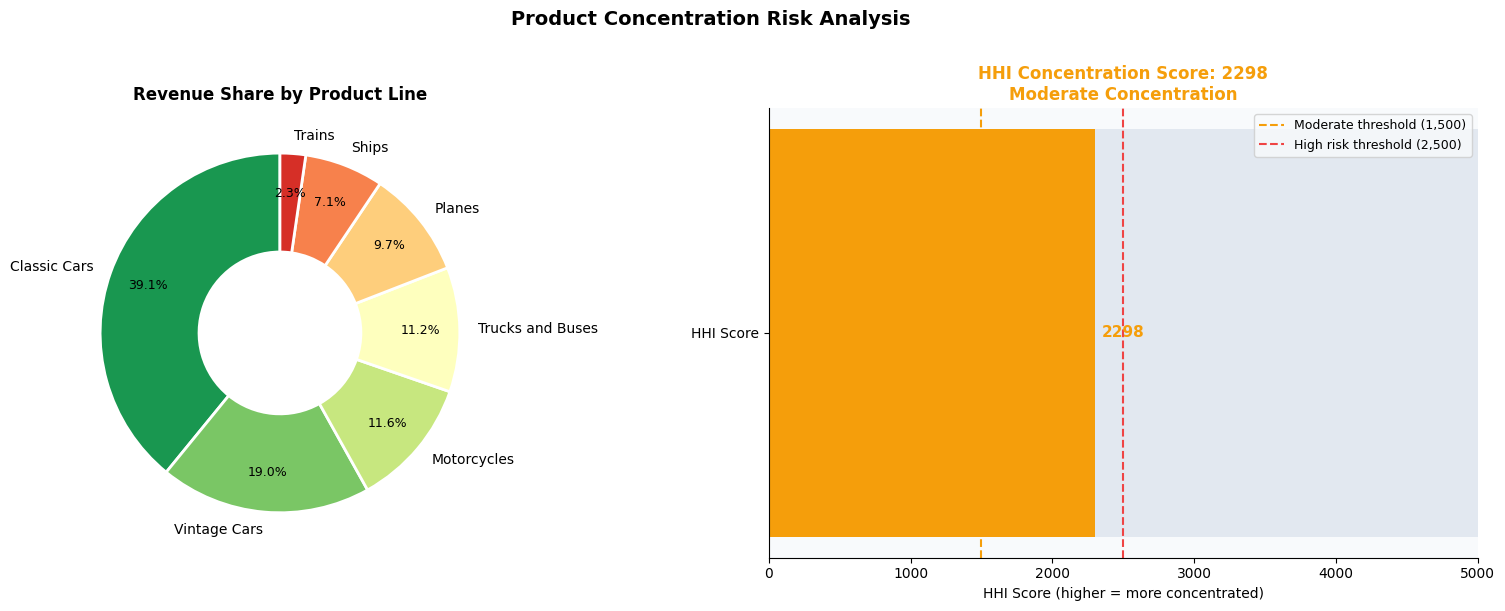

In [18]:
# Visualise concentration risk
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Revenue share donut
share_colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(shares_df)))
wedges, texts, autotexts = axes[0].pie(
    shares_df['revenue_share_%'],
    labels=shares_df[prod_col],
    autopct='%1.1f%%',
    colors=share_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.78,
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title('Revenue Share by Product Line', fontweight='bold')

# HHI gauge-style bar
hhi_max = 5000
axes[1].barh(['HHI Score'], [hhi], color=hhi_color,
             edgecolor='none', height=0.4)
axes[1].barh(['HHI Score'], [hhi_max], color='#E2E8F0',
             edgecolor='none', height=0.4)
axes[1].barh(['HHI Score'], [hhi], color=hhi_color,
             edgecolor='none', height=0.4)
axes[1].axvline(1500, color=C['star'], linestyle='--',
                linewidth=1.5, label='Moderate threshold (1,500)')
axes[1].axvline(2500, color=C['dog'], linestyle='--',
                linewidth=1.5, label='High risk threshold (2,500)')
axes[1].set_xlim(0, hhi_max)
axes[1].set_title(f'HHI Concentration Score: {hhi:.0f}\n{hhi_label}',
                  fontweight='bold', color=hhi_color)
axes[1].set_xlabel('HHI Score (higher = more concentrated)')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])
axes[1].text(hhi + 50, 0, f'{hhi:.0f}', va='center', fontsize=11,
             fontweight='bold', color=hhi_color)

plt.suptitle('Product Concentration Risk Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/concentration_risk.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 9: Product Performance Quadrant

We classify each product line into one of four strategic quadrants based on revenue and order volume, inspired by the BCG growth-share matrix:

| Quadrant | Revenue | Order Volume | Strategy |
|----------|---------|--------------|----------|
| Stars | High | High | Invest and protect |
| Cash Cows | High | Low | Maintain and extract |
| Question Marks | Low | High | Investigate and improve |
| Dogs | Low | Low | Review and consider phasing out |


In [19]:
# Build quadrant data
quad_df = prod_revenue.copy()

rev_median    = quad_df['total_revenue'].median()
orders_median = quad_df['orders'].median()

def classify_product(row):
    high_rev    = row['total_revenue'] >= rev_median
    high_orders = row['orders']        >= orders_median
    if high_rev and high_orders:
        return 'Star'
    elif high_rev and not high_orders:
        return 'Cash Cow'
    elif not high_rev and high_orders:
        return 'Question Mark'
    else:
        return 'Dog'

quad_df['quadrant'] = quad_df.apply(classify_product, axis=1)

quad_colors_map = {
    'Star':          C['star'],
    'Cash Cow':      C['cow'],
    'Question Mark': C['question'],
    'Dog':           C['dog'],
}

fig = px.scatter(
    quad_df,
    x='orders',
    y='total_revenue',
    color='quadrant',
    color_discrete_map=quad_colors_map,
    size='avg_order_value',
    hover_name=prod_col,
    hover_data={
        'total_revenue':   ':,.0f',
        'orders':          ':,',
        'avg_order_value': ':,.0f',
        'quadrant':        False,
    },
    text=prod_col,
    title='Product Performance Quadrant (size = avg order value)',
    labels={
        'orders':        'Order Volume',
        'total_revenue': 'Total Revenue',
        'quadrant':      'Classification',
    },
)
fig.add_vline(x=orders_median, line_dash='dash',
              line_color=C['subtext'], line_width=1.5)
fig.add_hline(y=rev_median, line_dash='dash',
              line_color=C['subtext'], line_width=1.5)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(
    height=520,
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
    legend_title_text='Quadrant',
)
fig.show()

print('Product Quadrant Classification:')
print(quad_df[[prod_col,'quadrant','total_revenue','orders']].to_string(index=False))


Product Quadrant Classification:
     productline      quadrant  total_revenue  orders
    Classic Cars          Star     3919615.66     967
    Vintage Cars          Star     1903150.84     607
     Motorcycles          Star     1166388.34     331
Trucks and Buses      Cash Cow     1127789.84     301
          Planes Question Mark      975003.57     306
           Ships           Dog      714437.13     234
          Trains           Dog      226243.47      77


---
## Section 10: Executive Summary Dashboard

In [20]:
total_revenue    = df[rev_col].sum()
total_orders     = df[order_col].nunique() if order_col else len(df)
top_product      = prod_revenue.iloc[0][prod_col]
top_product_pct  = prod_revenue.iloc[0]['total_revenue'] / total_revenue * 100
best_quarter_num = df.groupby('quarter')[rev_col].sum().idxmax()
star_count       = (quad_df['quadrant'] == 'Star').sum()

kpis = [
    ('Total Revenue',        f'{total_revenue:,.0f}',    'across all products and periods',      C['cow']),
    ('Total Orders',         f'{total_orders:,}',        'unique order transactions',            C['primary']),
    ('Top Product Line',     top_product,                f'{top_product_pct:.1f}% of revenue',   C['star']),
    ('Best Quarter',         f'Q{best_quarter_num}',     'highest revenue quarter',              C['cow']),
    ('HHI Score',            f'{hhi:.0f}',               hhi_label,                              hhi_color),
    ('Star Products',        f'{star_count}',            'high revenue and high order volume',   C['star']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Product Performance | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)
for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx, cy = col + 0.5, row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=17, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')
fig.show()


---
## Section 11: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| A small number of product lines dominate total revenue | Pareto analysis |
| Revenue concentration risk is measurable and actionable | HHI score |
| Product lines differ significantly in average order value, not just volume | AOV chart |
| Seasonal patterns exist with one quarter consistently outperforming others | Quarterly analysis |
| Each product line falls into a distinct strategic quadrant | BCG-style matrix |

---

### Recommendations

**1. Protect Your Star Products First**

Stars have both high revenue and high order volume. Any supply, pricing, or quality issue here has an outsized impact on the business. These products deserve priority in inventory management, supplier relationships, and quality control.

**2. Investigate the Question Marks**

High order volume but low revenue means customers are buying frequently but not spending much. Either the price point is too low or basket size needs increasing. A targeted upsell strategy for these product lines could shift them into Star territory.

**3. Reduce Concentration Risk if HHI is Above 2,500**

An HHI above 2,500 signals dangerous dependence on a small number of products. If the top product faces disruption, the business takes a disproportionate hit. This is an argument for investing in developing secondary product lines to broaden the revenue base.

**4. Time Campaigns Around Your Best Quarter**

Seasonal patterns are real and consistent. Aligning new product launches, promotions, and marketing spend with the strongest quarter amplifies results without increasing the cost base.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
